# Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('online_shoppers_intention.csv')

# Task 1

## 1.1

In [2]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
df.describe().round(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00,12330.00
mean,2.32,80.82,0.50,34.47,31.73,1194.75,0.02,0.04,5.89,0.06,2.12,2.36,3.15,4.07
std,3.32,176.78,1.27,140.75,44.48,1913.67,0.05,0.05,18.57,0.20,0.91,1.72,2.40,4.03
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,7.00,184.14,0.00,0.01,0.00,0.00,2.00,2.00,1.00,2.00
50%,1.00,7.50,0.00,0.00,18.00,598.94,0.00,0.03,0.00,0.00,2.00,2.00,3.00,2.00
75%,4.00,93.26,0.00,0.00,38.00,1464.16,0.02,0.05,0.00,0.00,3.00,2.00,4.00,4.00
max,27.00,3398.75,24.00,2549.38,705.00,63973.52,0.20,0.20,361.76,1.00,8.00,13.00,9.00,20.00


## 1.1

First of all, we show the difference in mean of five features beteween no purchase and purchase by using label data.

In [5]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
    ]
story_table = df.groupby("Revenue")[story_features].mean().T
story_table.columns = ["No purchase", "Purchase"]
story_table

,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555
PageValues,1.975998,27.264518


,No purchase,Purchase
ProductRelated,28.714642,48.210168
ProductRelated_Duration,1069.987809,1876.209615
BounceRates,0.025317,0.005117
ExitRates,0.047378,0.019555


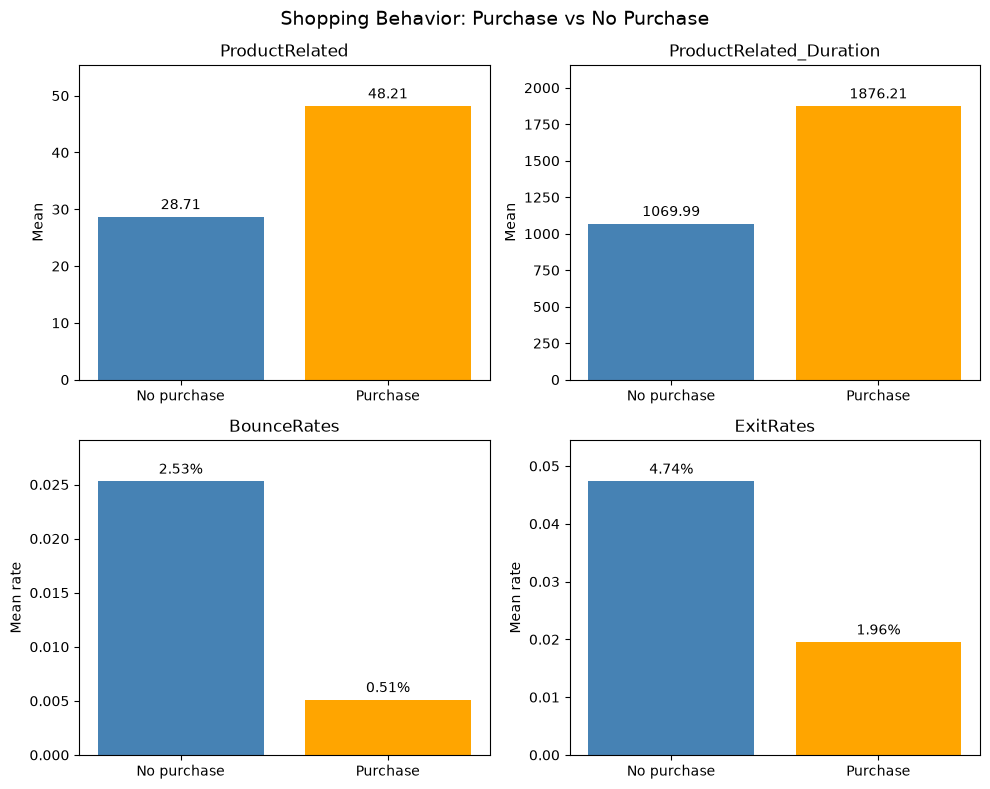

In [6]:
story_features = [
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
    ]
story_table = (df.groupby("Revenue")[story_features].mean().T)
story_table.columns = ["No purchase", "Purchase"]
display(story_table)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, story_features):
    values = story_table.loc[feature]
    bars = ax.bar(["No purchase", "Purchase"], values, color=["steelblue", "orange"])

    # BounceRate and ExitRate are easier to understand as percentages
    if feature in ["BounceRates", "ExitRates"]:
        labels = [f"{value:.2%}" for value in values]
        ax.set_ylabel("Mean rate")

    else:
        labels = [f"{value:.2f}" for value in values]
        ax.set_ylabel("Mean")

    ax.set_ylim(top=values.max() * 1.15)
    ax.bar_label(bars, labels=labels, padding=3)
    ax.set_title(feature)


fig.suptitle("Shopping Behavior: Purchase vs No Purchase", fontsize=14)

plt.tight_layout()
plt.show()

### Dataset first exploration

We compared sessions that resulted in a purchase with sessions that did not.  
The clearest difference is that purchasing sessions show much stronger engagement with product pages. On average, they viewed about 48 product-related pages, compared to about 29 pages for non-purchasing sessions. They also spent much more time on these pages: around 1,876 seconds, compared to 1,070 seconds.  
At the same time, purchasing sessions had much lower bounce and exit rates. The average bounce rate decreased from about 2.53% to 0.51%, while the exit rate decreased from 4.74% to 1.96%.  
Overall, the data suggests that sessions resulting in purchases are characterized by more product exploration, longer browsing time, and lower bounce and exit rates.

## 1.2

In [7]:
df["BrowserGroup"] = np.where(df["Browser"] == 13, "Browser 13", "Other browsers")
print(df["BrowserGroup"].value_counts())

BrowserGroup
Other browsers    12269
Browser 13           61
Name: count, dtype: int64


In [8]:
story_table = df.groupby("BrowserGroup").mean(numeric_only=True).T
story_table.columns = ["Other Browsers", "Browser 13"]
story_table

,Other Browsers,Browser 13
Administrative,1.754098,2.317956
Administrative_Duration,73.716530,80.853921
Informational,0.229508,0.504931
Informational_Duration,4.717486,34.620336
ProductRelated,14.885246,31.815225
ProductRelated_Duration,699.388395,1197.209080
BounceRates,0.034373,0.022131
ExitRates,0.052842,0.043024
PageValues,26.268249,5.787936
SpecialDay,0.000000,0.061733


,Other Browsers,Browser 13,Difference (%)
Informational_Duration,34.620336,4.717486,-86.373655
Informational,0.504931,0.229508,-54.546633
ProductRelated,31.815225,14.885246,-53.213451
ProductRelated_Duration,1197.209080,699.388395,-41.581767
Administrative,2.317956,1.754098,-24.325635
Administrative_Duration,80.853921,73.716530,-8.827514
ExitRates,0.043024,0.052842,22.820300
BounceRates,0.022131,0.034373,55.316528


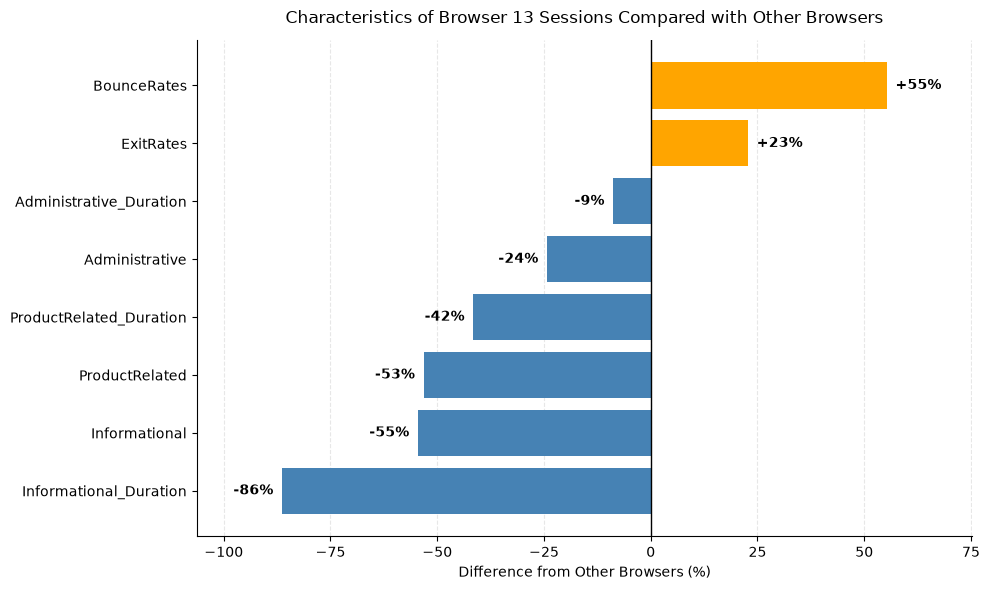

In [9]:
features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates"
    ]

browser13 = df[df["Browser"] == 13]
others = df[df["Browser"] != 13]

comparison_table = pd.DataFrame({
    "Other Browsers": others[features].mean(),
    "Browser 13": browser13[features].mean()
    })

# Percentage difference compared with other browsers
comparison_table["Difference (%)"] = (
    (comparison_table["Browser 13"]
     - comparison_table["Other Browsers"])
    / comparison_table["Other Browsers"]
) * 100

# Sort for easier interpretation
comparison_table = comparison_table.sort_values("Difference (%)")
display(comparison_table)


# -------------------------
# Visualization
# -------------------------

fig, ax = plt.subplots(figsize=(10, 6))

differences = comparison_table["Difference (%)"]

# Different colors:
# negative = Browser 13 lower
# positive = Browser 13 higher
colors = ["steelblue" if value < 0 else "orange" for value in differences]

bars = ax.barh(comparison_table.index, differences, color=colors)

# Zero reference line
ax.axvline(0, color="black", linewidth=1)

# Percentage labels
for bar, value in zip(bars, differences):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 2,
            y,
            f"+{value:.0f}%",
            va="center",
            ha="left",
            fontsize=10,
            fontweight="bold"
        )

    else:
        ax.text(
            value - 2,
            y,
            f"{value:.0f}%",
            va="center",
            ha="right",
            fontsize=10,
            fontweight="bold"
        )


# Give labels enough room
xmin = differences.min() - 20
xmax = differences.max() + 20

ax.set_xlim(xmin, xmax)
ax.set_xlabel("Difference from Other Browsers (%)")
ax.set_title("Characteristics of Browser 13 Sessions Compared with Other Browsers", pad=12)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid for readability
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Plot overview

This chart compares the average characteristics of Browser 13 sessions with those of all other browser sessions.  
Each bar shows the percentage difference between the Browser 13 mean and the mean for other browsers. Positive values mean Browser 13 is higher, while negative values mean Browser 13 is lower.

### Observations

Browser 13 sessions show much lower browsing engagement than sessions using other browsers.  
They visit fewer administrative pages (-24%), informational pages (-55%), and product-related pages (-53%). They also spend less time on these page types, especially on informational pages, where the average duration is about 86% lower. Product-related duration is also about 42% lower.  
At the same time, Browser 13 sessions have a 55% higher bounce rate and a 23% higher exit rate.  
Overall, this suggests that Browser 13 sessions tend to be shorter and involve less interaction with the website.

# Task 2

### Normalization

According to the documentation, before the clustering analysis, the data frame needs to be preprocessed.  
Numerical variables will be standardized using StandardScaler, while nominal variables will be one-hot encoded. Boolean variables will be turned into 0/1 values.

* Applying the log transformation to strongly right-skewed numerical features
* Applying the StandardScaler to numerical variables
* one-hot encoding for the nominal variables
* Boolean variables will be turned into 0/1 values

In [10]:
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("online_shoppers_intention.csv")

# Separate the class label
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"]).copy()

# Convert binary variable
X["Weekend"] = X["Weekend"].astype(int)

# Define numerical features
numerical_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
    ]

# Strongly right-skewed numerical features
log_columns = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "PageValues"
    ]

# Nominal categorical features
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType"
    ]

# Reduce skewness of strongly skewed numerical features
X[log_columns] = np.log1p(X[log_columns])

# Scale numerical features only
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

# One-hot encode nominal features
# These remain 0/1 and are NOT standardized
X = pd.get_dummies(X, columns=categorical_columns, dtype=int)

# Keep the variable name used in the later tasks
X_scaled_cleaned = X.to_numpy(dtype=float)

# Make df.columns correspond to the preprocessed matrix
# so your later code works:
# pd.DataFrame(X_scaled_cleaned, columns=df.columns)
df = X.copy()

print("Original number of rows:", X.shape[0])
print("Number of features after preprocessing:", X.shape[1])

display(X.head().round(2))

Original number of rows: 12330
Number of features after preprocessing: 74


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.92,-0.98,-0.48,-0.46,-1.95,-2.92,3.67,3.23,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
1,-0.92,-0.98,-0.48,-0.46,-1.59,-0.88,-0.46,1.17,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
2,-0.92,-0.98,-0.48,-0.46,-1.95,-2.92,3.67,3.23,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
3,-0.92,-0.98,-0.48,-0.46,-1.59,-2.28,0.57,1.99,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1
4,-0.92,-0.98,-0.48,-0.46,-0.43,0.24,-0.05,0.14,-0.49,-0.31,...,0,0,0,0,0,0,0,0,0,1


# Task 3

## Affinity Propagation, DBSCAN and BIRCH clustering

In [49]:
from sklearn.cluster import AffinityPropagation, DBSCAN, Birch
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


# Prepare data
df_scaled_cleaned = pd.DataFrame(X_scaled_cleaned, columns=df.columns)

# NOTE: maybe tweak how the sampling is done to be more clever. Find a way to reduce the number of feature
# NOTE: tweak the sample size
# Same sample is used for ALL clustering methods
SAMPLE_SIZE = int(len(df_scaled_cleaned) * 0.08)
RANDOM_STATE = 42

# NOTE: make statistics of before and after sampling to make sure it is still representative

df_sample = df_scaled_cleaned.sample(
    n=min(SAMPLE_SIZE, len(df_scaled_cleaned)),
    random_state=RANDOM_STATE)

# Full-dimensional data used for clustering
X_cluster = df_sample.to_numpy()

print("Sample size:", X_cluster.shape[0])
print("Number of features:", X_cluster.shape[1])

Sample size: 986
Number of features: 74


## 3.1: Affinity Propagation Clustering

In [50]:
AP_PREFERENCE = -3000

affinity_model = AffinityPropagation(
    damping=0.9,
    preference=AP_PREFERENCE,
    max_iter=300,
    convergence_iter=15,
    random_state=RANDOM_STATE)

labels_ap = affinity_model.fit_predict(X_cluster)

n_clusters_ap = len(np.unique(labels_ap))

print("Affinity Propagation")
print("Preference:", AP_PREFERENCE)
print("Number of clusters:", n_clusters_ap)

print(pd.Series(labels_ap).value_counts().sort_index())

Affinity Propagation
Preference: -3000
Number of clusters: 2
0    495
1    491
Name: count, dtype: int64


## 3.2: DBSCAN Clustering

In [51]:
MIN_SAMPLES = 5

# Find distance to the 5th nearest neighbour
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES)
neighbors.fit(X_cluster)
distances, _ = neighbors.kneighbors(X_cluster)

k_distances = np.sort(distances[:, -1])

DBSCAN_EPS = 2.25
dbscan_model = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan_model.fit_predict(X_cluster)

n_clusters_dbscan = len(set(labels_dbscan) - {-1})

n_noise = np.sum(labels_dbscan == -1)

print("Number of clusters:", n_clusters_dbscan)
print("Number of noise points:", n_noise)

print(pd.Series(labels_dbscan).value_counts().sort_index())

Number of clusters: 7
Number of noise points: 453
-1    453
 0    444
 1      8
 2     11
 3     54
 4      7
 5      5
 6      4
Name: count, dtype: int64


In [52]:
eps_values = [
    1.5,
    2.0,
    2.25,
    2.5,
    2.75,
    3.0
    ]

for eps in eps_values:

    model = DBSCAN(eps=eps, min_samples=MIN_SAMPLES)
    labels = model.fit_predict(X_cluster)

    n_clusters = len(set(labels) - {-1})

    noise_ratio = np.mean(labels == -1)

    print(f"eps={eps:.2f} | clusters={n_clusters} | noise={noise_ratio:.1%}")

eps=1.50 | clusters=5 | noise=95.6%
eps=2.00 | clusters=6 | noise=75.7%
eps=2.25 | clusters=7 | noise=45.9%
eps=2.50 | clusters=4 | noise=23.8%
eps=2.75 | clusters=1 | noise=9.7%
eps=3.00 | clusters=1 | noise=2.8%


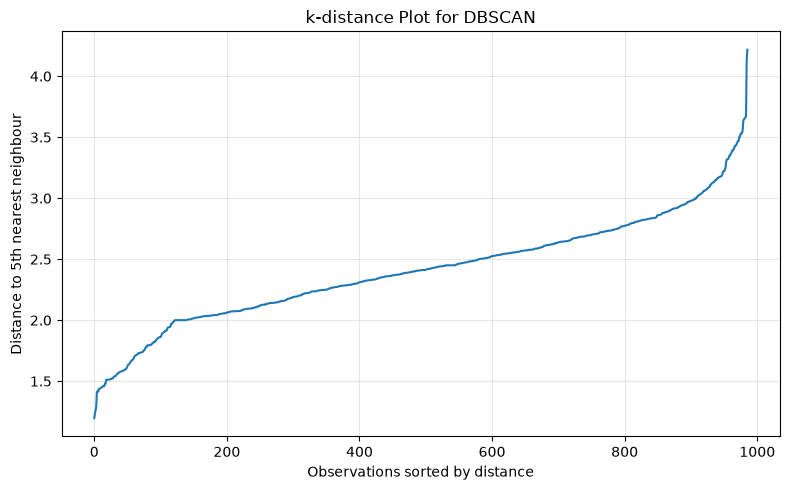

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Observations sorted by distance")
plt.ylabel(f"Distance to {MIN_SAMPLES}th nearest neighbour")
plt.title("k-distance Plot for DBSCAN")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [54]:
noise_ratio = np.mean(labels_dbscan == -1)

print(f"Noise points: {n_noise} / {len(labels_dbscan)} ({noise_ratio:.2%})")

Noise points: 453 / 986 (45.94%)


## 3.3: BIRCH Clustering

In [55]:
BIRCH_N_CLUSTERS = 7

birch_model = Birch(n_clusters=BIRCH_N_CLUSTERS)
labels_birch = birch_model.fit_predict(X_cluster)

n_clusters_birch = len(np.unique(labels_birch))

print("Birch")
print("Number of clusters:", n_clusters_birch)

print(pd.Series(labels_birch).value_counts().sort_index())

Birch
Number of clusters: 7
0    137
1     94
2    221
3    294
4     69
5    130
6     41
Name: count, dtype: int64


### Visualization

PCA is used only for visualization.  
The first two principal components explain about 44% of the variance, so the two-dimensional plots do not show all of the cluster structure used by the algorithms.

In [56]:
# PCA — visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)
pc1_ratio = pca.explained_variance_ratio_[0] * 100

pc2_ratio = pca.explained_variance_ratio_[1] * 100

print(f"PC1: {pc1_ratio:.2f}%")
print(f"PC2: {pc2_ratio:.2f}%")

print(f"PC1 + PC2: {pc1_ratio + pc2_ratio:.2f}%")

PC1: 33.45%
PC2: 12.49%
PC1 + PC2: 45.94%


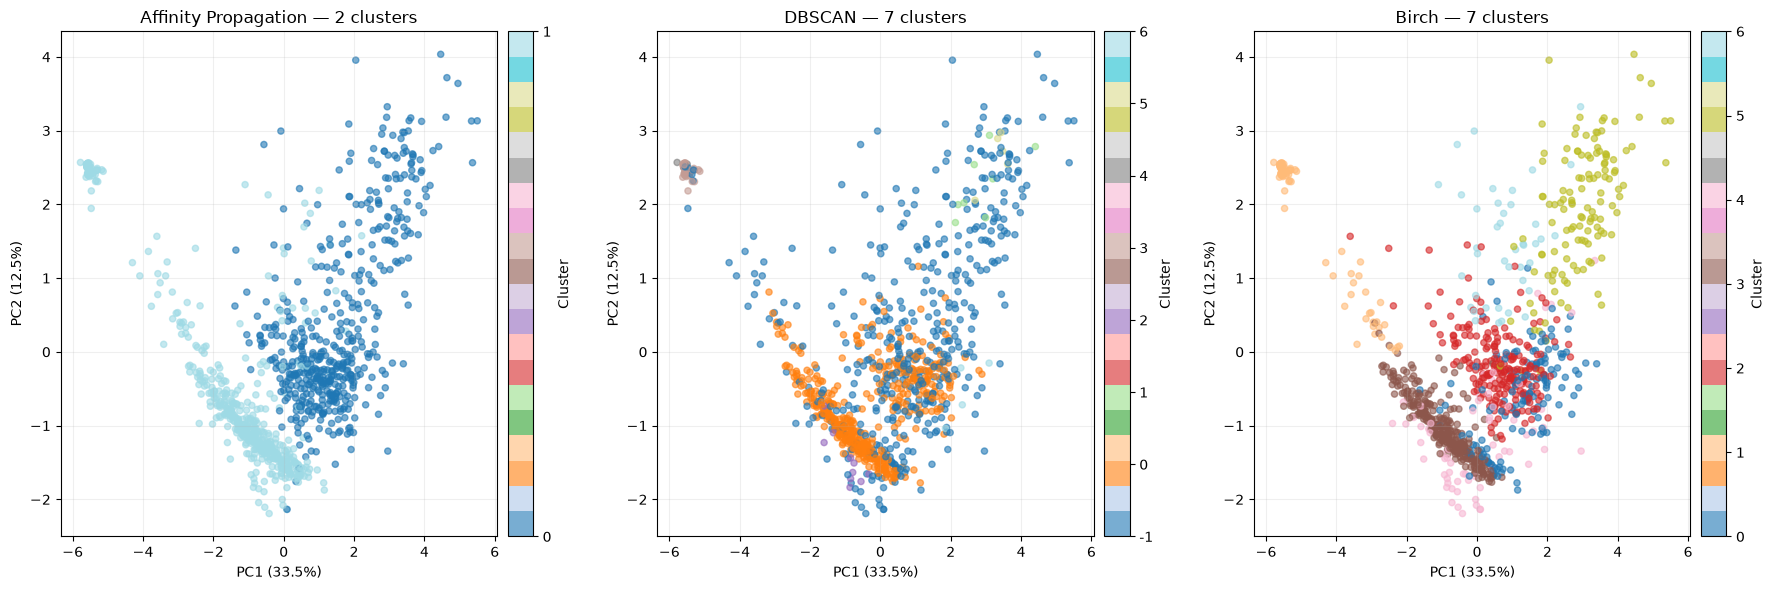

In [57]:
results = [
    ("Affinity Propagation", labels_ap),
    ("DBSCAN", labels_dbscan),
    ("Birch", labels_birch)
    ]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))


for ax, (name, labels) in zip(axes, results):

    unique_labels = sorted(np.unique(labels))
    n_clusters = len(set(labels) - {-1})

    # Convert cluster IDs to consecutive integers
    # for visualization
    label_map = {label: i for i, label in enumerate(unique_labels)}
    plot_labels = np.array([label_map[label] for label in labels])

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=plot_labels,
        cmap="tab20",
        s=20,
        alpha=0.6)

    ax.set_xlabel(f"PC1 ({pc1_ratio:.1f}%)")
    ax.set_ylabel(f"PC2 ({pc2_ratio:.1f}%)")
    ax.set_title(f"{name} — {n_clusters} clusters")
    ax.grid(alpha=0.2)

    # Avoid unreadable colorbars when there
    # are too many clusters
    if len(unique_labels) <= 15:
        colorbar = fig.colorbar(
            scatter,
            ax=ax,
            ticks=range(len(unique_labels)),
            pad=0.02)
        colorbar.set_label("Cluster")
        colorbar.set_ticklabels(unique_labels)


plt.tight_layout()
plt.show()

### Observation

The clustering was performed in the full preprocessed feature space, while PCA was used only for visualization. PC1 and PC2 explain about 31.6% and 12.4% of the variance respectively, so the figure displays about 44% of the total variance.

### Comparison

| Method | Main idea | Need number of clusters beforehand? | Can detect noise? | Important parameter | Your current result |
|---|---|---|---|---|---|
| Affinity Propagation | Chooses representative points called **exemplars** and groups similar points around them | No | No | `preference` | 10 clusters |
| DBSCAN | Finds clusters as **dense regions** of points | No | Yes (`-1` = noise) | `eps`, `min_samples` | 3 clusters + noise |
| Birch | Builds compact **hierarchical summaries/subclusters**, then forms final clusters | Usually yes in your setup | No | `n_clusters` | 7 clusters |

# Task 4

## 4.1: Silhouette Score

For one observation $i$:


$$ a(i)=\text{average distance from }i\text{ to points in its own cluster}$$

and
$$b(i)=\text{smallest average distance from }i\text{ to any other cluster}$$
Then:
$$s(i)=\frac{b(i)-a(i)}
{\max(a(i),b(i))}$$

Interpretation:
- close to 1 → well clustered
- close to 0 → clusters overlap
- negative → probably assigned to the wrong cluster

The final Silhouette score is the average of $s(i)$ over all observations.

In [ ]:
import math

def euclidean_distance(point1, point2):
    """
    Manually calculate Euclidean distance.
    """
    total = 0.0
    for x, y in zip(point1, point2):
        total += (x - y) ** 2
    return math.sqrt(total)

# NOTE: Lookup if X is really needed, previous version maybe simpler
def manual_silhouette_score(X, labels):
    """
    Manually calculate the mean Silhouette score.

    Noise points with label -1 are excluded.
    """
    # NOTE: factorise the noise cleaning in a function, it's used multiple somewhere else
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Remove DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    unique_clusters = np.unique(labels_eval)

    if len(unique_clusters) < 2:
        return np.nan

    silhouette_values = []

    for i in range(len(X_eval)):

        current_cluster = labels_eval[i]

        # a(i): same-cluster distance
        same_cluster_indices = [j for j in range(len(X_eval)) if labels_eval[j] == current_cluster and j != i]

        # A cluster containing only one point
        if len(same_cluster_indices) == 0:
            silhouette_values.append(0.0)
            continue

        a_i = 0.0

        for j in same_cluster_indices:
            a_i += euclidean_distance(X_eval[i], X_eval[j])

        a_i /= len(same_cluster_indices)

        # b(i): nearest other cluster
        b_i = float("inf")

        for cluster in unique_clusters:
            if cluster == current_cluster:
                continue
            other_cluster_indices = [j for j in range(len(X_eval)) if labels_eval[j] == cluster]
            average_distance = 0.0
            for j in other_cluster_indices:
                average_distance += euclidean_distance(X_eval[i], X_eval[j])
            average_distance /= len(other_cluster_indices)
            if average_distance < b_i:
                b_i = average_distance
        # Silhouette for point i
        denominator = max(a_i, b_i)
        if denominator == 0:
            s_i = 0.0
        else:
            s_i = (b_i - a_i) / denominator
        silhouette_values.append(s_i)

    return sum(silhouette_values) / len(silhouette_values)

silhouette_ap = manual_silhouette_score(X_cluster, labels_ap)
silhouette_dbscan = manual_silhouette_score(X_cluster, labels_dbscan)
silhouette_birch = manual_silhouette_score(X_cluster, labels_birch)

print("Affinity Propagation:", silhouette_ap)
print("DBSCAN:", silhouette_dbscan)
print("Birch:", silhouette_birch)

Affinity Propagation: 0.1759299139809674
DBSCAN: 0.1233874001208554
Birch: 0.185386364572598


## 4.2: Davies Bouldin Score

The lower the score is, the better the clusters are.  
A smaller Davies–Bouldin means that clusters are more compact and better separated.

In [59]:
from sklearn.metrics import davies_bouldin_score


def evaluate_davies_bouldin(X, labels):
    """
    Calculate the Calinski-Harabasz Index for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Calinski-Harabasz Index
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Exclude DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return davies_bouldin_score(X_eval, labels_eval)


db_ap = evaluate_davies_bouldin(X_pca, labels_ap)
db_dbscan = evaluate_davies_bouldin(X_pca, labels_dbscan)
db_birch = evaluate_davies_bouldin(X_pca, labels_birch)

print("Affinity Propagation:", db_ap)
print("DBSCAN:", db_dbscan)
print("Birch:", db_birch)

Affinity Propagation: 1.0486465330782497
DBSCAN: 1.9751243675842933
Birch: 1.6370968505436476


## 4.3: Calinski-Harabasz Index 

In [60]:
from sklearn.metrics import calinski_harabasz_score


def evaluate_calinski_harabasz(X, labels):
    """
    Calculate the Calinski-Harabasz Index for a clustering result.

    Parameters:
        X      : Data points used for clustering
        labels : Cluster labels assigned to each data point

    Returns:
        Calinski-Harabasz Index
    """
    X = np.asarray(X)
    labels = np.asarray(labels)

    # Exclude DBSCAN noise
    mask = labels != -1

    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return np.nan

    return calinski_harabasz_score(X_eval, labels_eval)


ch_ap = evaluate_calinski_harabasz(X_cluster, labels_ap)
ch_dbscan = evaluate_calinski_harabasz(X_cluster, labels_dbscan)
ch_birch = evaluate_calinski_harabasz(X_cluster, labels_birch)

print("Affinity Propagation:", ch_ap)
print("DBSCAN:", ch_dbscan)
print("Birch:", ch_birch)

Affinity Propagation: 237.76092962905034
DBSCAN: 65.33572254104838
Birch: 182.45171413646096


In [61]:
results_task4 = pd.DataFrame({
    "Silhouette ↑": [
        silhouette_ap,
        silhouette_dbscan,
        silhouette_birch
    ],
    "Davies-Bouldin ↓": [
        db_ap,
        db_dbscan,
        db_birch
    ],
    "Calinski-Harabasz ↑": [
        ch_ap,
        ch_dbscan,
        ch_birch
    ]
},
index=[
    "Affinity Propagation",
    "DBSCAN",
    "Birch"
])

display(results_task4.round(3))

,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
Affinity Propagation,0.176,1.049,237.761
DBSCAN,0.123,1.975,65.336
Birch,0.185,1.637,182.452


# Task 5

## 5.1: Euclidean distance + DBSCAN

The Euclidean distance function was manually implemented in task 4.1.  
Since the function does not use any predefined distance functions or libraries, we reuse the same implementation here as the distance metric for DBSCAN.

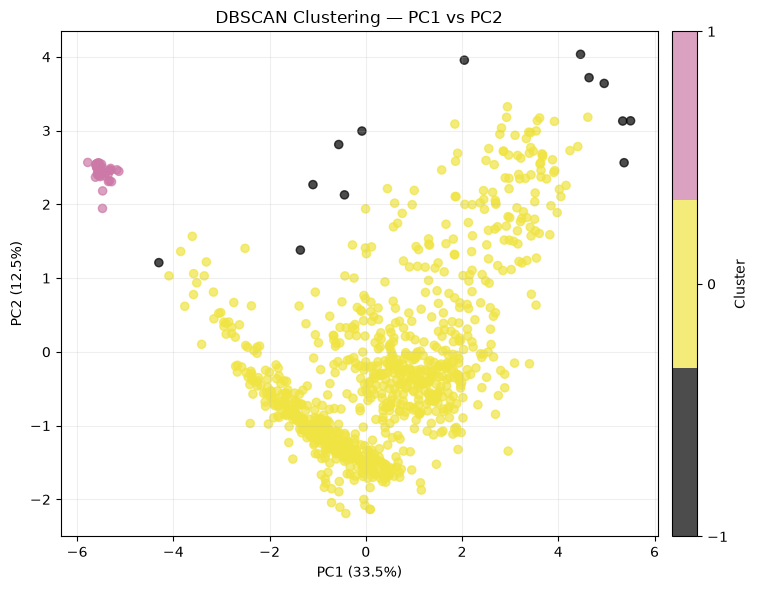

In [62]:
dbscan = DBSCAN(eps=0.8, min_samples=15, metric=euclidean_distance)

labels_euclidean = dbscan.fit_predict(X_pca)

unique_labels = np.unique(labels_euclidean)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))
scatter = ax.scatter(
    X_pca[:, 0],       # PC1
    X_pca[:, 1],       # PC2
    c=labels_euclidean,
    cmap=cmap,
    alpha=0.7,
    s=35)

# Only show a limited number of colourbar labels
colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)
colorbar.set_label("Cluster")

# Axis labels
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("DBSCAN Clustering — PC1 vs PC2")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 5.2: Manhattan distance + DBSCAN

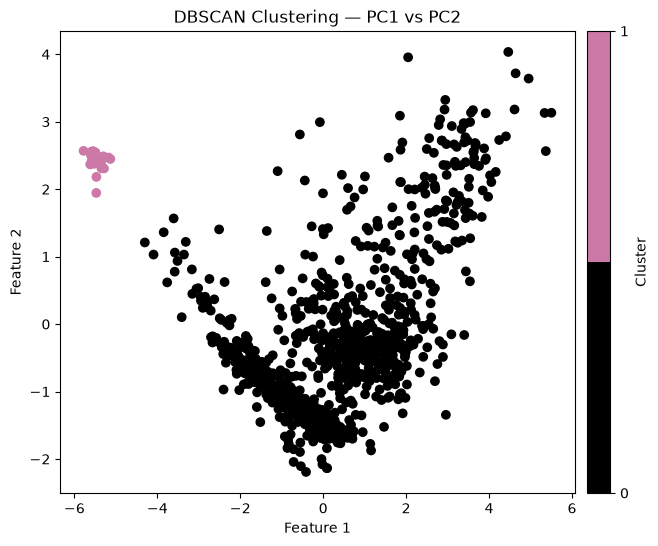

In [63]:
def manhattan_distance(point1, point2):
    assert(len(point1) == len(point2))
    distance = 0
    for x1, x2 in zip(point1, point2):
        distance += abs(x1 - x2)
    return distance

dbscan = DBSCAN(eps=1.65, min_samples=12, metric=manhattan_distance)

labels_manhattan = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels_manhattan)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_manhattan,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("DBSCAN Clustering — PC1 vs PC2")

plt.show()

## 5.3: Cosine similarity distance + DBSCAN

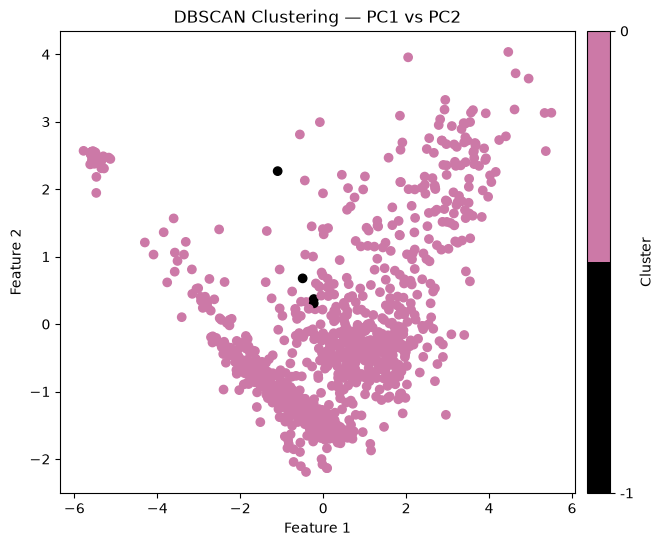

In [64]:
def cosine_distance(point1, point2):
    dot_product = 0
    magnitude1 = 0
    magnitude2 = 0

    for x1, x2 in zip(point1, point2):
        dot_product += x1 * x2
        magnitude1 += x1 * x1
        magnitude2 += x2 * x2

    magnitude1 = math.sqrt(magnitude1)
    magnitude2 = math.sqrt(magnitude2)

    if magnitude1 == 0 or magnitude2 == 0:
        return 0

    cosine_similarity = dot_product / (magnitude1 * magnitude2)

    return 1 - cosine_similarity

dbscan = DBSCAN(eps=0.03, min_samples=15, metric=cosine_distance)

labels_cosine = dbscan.fit_predict(X_pca)
unique_labels = np.unique(labels_cosine)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap("okabe_ito", max(len(unique_labels), 1))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_cosine,
    cmap=cmap)

colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=unique_labels,
    pad=0.02)

colorbar.set_label("Cluster")
colorbar.set_ticklabels(unique_labels)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("DBSCAN Clustering — PC1 vs PC2")

plt.show()

## 5.4: Evaluate different distance functions

In [ ]:
# Calculate silhouette values for each distance function
from numpy import iterable

# NOTE: Check 'X' parameter, output 'nan' for the moment, just for cosine right now
score_euclidean = manual_silhouette_score(X_cluster, labels_euclidean)
score_manhattan = manual_silhouette_score(X_cluster, labels_manhattan)
score_cosine = manual_silhouette_score(X_cluster, labels_cosine)

# NOTE: remove if unused in the end
def flatten_list(l):
    flatened_l = []
    for val in l:
        if iterable(val):
            flatened_l.extend(val)
        else:
            flatened_l.append(val)
    return flatened_l

# Print the results
print("Euclidean silhouette score:", score_euclidean)
print("Manhattan silhouette score:", score_manhattan)
print("Cosine silhouette score:", score_cosine)

Euclidean silhouette score: 0.3851499973651807
Manhattan silhouette score: 0.37987060726655714
Cosine silhouette score: nan


### Silhouette interpretation:

s > 0.7: strong cluster structure  
s > 0.5: reasonable cluster structure  
s > 0.25: weak cluster structure  
s < 0.25: no cluster structure

### Visualisation of the different silhouette scores

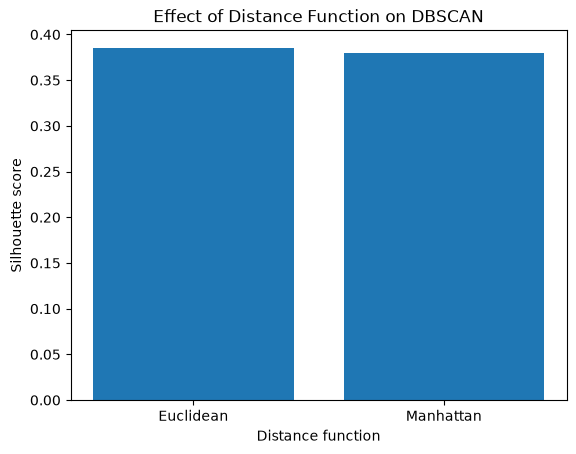

In [66]:
distance_functions = ["Euclidean", "Manhattan", "Cosine"]
silhouette_scores = [score_euclidean, score_manhattan, score_cosine]

plt.bar(distance_functions, silhouette_scores)

plt.xlabel("Distance function")
plt.ylabel("Silhouette score")
plt.title("Effect of Distance Function on DBSCAN")

plt.show()